# Notebook 04 – Feature Engineering

## Objectif

Ce notebook transforme les données préparées dans le Notebook précédent en variables
quantitatives décrivant le comportement économique des produits.

Les variables construites couvrent quatre dimensions :

1. le niveau économique courant ;
2. les évolutions entre N et N-1 ;
3. le positionnement par rapport aux EAN du même contexte métier ;
4. le positionnement par rapport à l'historique propre de l'EAN.

Ces caractéristiques constituent la représentation utilisée dans les étapes de détection d'anomalies.


In [1]:
# Import des bibliothèques

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Chemins du projet

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = DATA_DIR / "results"
FEATURE_DIR = RESULTS_DIR / "feature_engineering"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = PROCESSED_DIR / "dataset_business.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset introuvable ")

df = pd.read_csv(
    DATASET_PATH,
    dtype={"EAN": "string", "Year": "Int64", "MonthLib": "string"}
)

print(f"Dataset chargé : {len(df):,} observations × {df.shape[1]} variables")

Dataset chargé : 68,324 observations × 15 variables


In [3]:
# Contrôle du schéma attendu
required_columns = [
    "EAN", "Year", "MonthLib",
    "International Department",
    "International Sub Department",
    "International Family",
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N",
    "Tx M3N MDH Inter N-1",
    "Tx M3N non CP N-1",
    "Average Purchasing Price N",
    "Average selling price N",
    "Average Purchasing Price N-1",
    "Average Selling Price N-1"
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Variables nécessaires absentes : {missing_columns}")

df_features = df.copy()

numeric_columns = [
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N",
    "Tx M3N MDH Inter N-1",
    "Tx M3N non CP N-1",
    "Average Purchasing Price N",
    "Average selling price N",
    "Average Purchasing Price N-1",
    "Average Selling Price N-1"
]

for column in numeric_columns:
    df_features[column] = pd.to_numeric(
        df_features[column], errors="coerce"
    )

print(" Structure et types économiques contrôlés.")

 Structure et types économiques contrôlés.


## 1. Variables économiques courantes

Les premières variables décrivent la situation économique de l'EAN sur la période
courante. Elles servent notamment à caractériser l'écart entre prix de vente et
prix d'achat ainsi que leur rapport relatif.

In [4]:
# Ecart prix de vente - prix d'achat

df_features["Price_Gap_N"] = (
    df_features["Average selling price N"]
    - df_features["Average Purchasing Price N"]
)

# Ratio prix de vente / prix d'achat
df_features["Price_Ratio_N"] = np.where(
    df_features["Average Purchasing Price N"] > 0,
    df_features["Average selling price N"]
    / df_features["Average Purchasing Price N"],
    np.nan
)

print("Variables courantes créées : Price_Gap_N, Price_Ratio_N")

Variables courantes créées : Price_Gap_N, Price_Ratio_N


## 2. Variables d'évolution entre N et N-1

Les évolutions relatives permettent de caractériser les ruptures de comportement
entre deux périodes de référence. Une variation relative n'est pas calculée
lorsque la valeur de référence N-1 est nulle ou non exploitable.

In [5]:
# Evolution relative du prix d'achat

df_features["Purchase_Price_Variation"] = np.where(
    df_features["Average Purchasing Price N-1"] > 0,
    (
        (df_features["Average Purchasing Price N"]
         - df_features["Average Purchasing Price N-1"])
        / df_features["Average Purchasing Price N-1"]
    ) * 100,
    np.nan
)

# Evolution relative du prix de vente
df_features["Selling_Price_Variation"] = np.where(
    df_features["Average Selling Price N-1"] > 0,
    (
        (df_features["Average selling price N"]
         - df_features["Average Selling Price N-1"])
        / df_features["Average Selling Price N-1"]
    ) * 100,
    np.nan
)

# Evolution de la marge internationale
df_features["Margin_MDH_Variation"] = np.where(
    df_features["Tx M3N MDH Inter N-1"] != 0,
    (
        (df_features["Tx M3N MDH Inter N"]
         - df_features["Tx M3N MDH Inter N-1"])
        / df_features["Tx M3N MDH Inter N-1"].abs()
    ) * 100,
    np.nan
)

# Evolution de la marge locale
df_features["Margin_Local_Variation"] = np.where(
    df_features["Tx M3N non CP N-1"] != 0,
    (
        (df_features["Tx M3N non CP N"]
         - df_features["Tx M3N non CP N-1"])
        / df_features["Tx M3N non CP N-1"].abs()
    ) * 100,
    np.nan
)

print(" Quatre variables d'évolution relative créées.")

 Quatre variables d'évolution relative créées.


## 3. Positionnement par rapport aux EAN comparables

La comparaison familiale est réalisée dans un même contexte **année × mois ×
département × sous-département × famille**.

Pour chaque variable, la médiane et le MAD sont calculés sur les observations
du groupe. Un groupe doit disposer d'au moins **5 valeurs valides** pour produire
un indicateur robuste.

Le Robust Z est ensuite calculé.

Lorsque la dispersion robuste est nulle ou insuffisante, le Robust Z reste
manquant plutôt que d'introduire une valeur artificielle.

In [6]:
peer_group = [
    "Year",
    "MonthLib",
    "International Department",
    "International Sub Department",
    "International Family"
]

MIN_PEER_OBS = 5

def robust_group_features(data, group_columns, value_column, prefix):
    """Calcule médiane, MAD, écart à la médiane et Robust Z par groupe."""
    grouped = data.groupby(group_columns, dropna=False)[value_column]

    median = grouped.transform("median")

    mad = grouped.transform(
        lambda s: (
            np.median(np.abs(s.dropna() - np.median(s.dropna())))
            if s.notna().sum() >= MIN_PEER_OBS
            else np.nan
        )
    )

    valid_count = grouped.transform("count")

    median = median.where(valid_count >= MIN_PEER_OBS, np.nan)
    mad = mad.where(valid_count >= MIN_PEER_OBS, np.nan)

    deviation = data[value_column] - median
    scale = 1.4826 * mad

    robust_z = np.where(scale > 1e-9, deviation / scale, np.nan)

    data[f"{prefix}_Median"] = median
    data[f"{prefix}_MAD"] = mad
    data[f"{prefix}_vs_Family"] = deviation
    data[f"{prefix}_Robust_Z"] = robust_z

    return data

df_features = robust_group_features(
    df_features, peer_group, "Average selling price N", "Family_Selling_Price"
)
df_features = robust_group_features(
    df_features, peer_group, "Average Purchasing Price N", "Family_Purchase_Price"
)
df_features = robust_group_features(
    df_features, peer_group, "Tx M3N MDH Inter N", "Family_Margin_MDH"
)
df_features = robust_group_features(
    df_features, peer_group, "Tx M3N non CP N", "Family_Margin_Local"
)

# Renommage des variables
rename_family = {
    "Family_Selling_Price_Median": "Family_Median_Selling_Price",
    "Family_Selling_Price_MAD": "Family_MAD_Selling_Price",
    "Family_Selling_Price_vs_Family": "Selling_Price_vs_Family",
    "Family_Selling_Price_Robust_Z": "Family_Robust_Z_Selling_Price",

    "Family_Purchase_Price_Median": "Family_Median_Purchase_Price",
    "Family_Purchase_Price_MAD": "Family_MAD_Purchase_Price",
    "Family_Purchase_Price_vs_Family": "Purchase_Price_vs_Family",
    "Family_Purchase_Price_Robust_Z": "Family_Robust_Z_Purchase_Price",

    "Family_Margin_MDH_Median": "Family_Median_Margin",
    "Family_Margin_MDH_MAD": "Family_MAD_Margin_MDH",
    "Family_Margin_MDH_vs_Family": "Margin_vs_Family",
    "Family_Margin_MDH_Robust_Z": "Family_Robust_Z_Margin_MDH",

    "Family_Margin_Local_Median": "Family_Median_Margin_Local",
    "Family_Margin_Local_MAD": "Family_MAD_Margin_Local",
    "Family_Margin_Local_vs_Family": "Margin_Local_vs_Family",
    "Family_Margin_Local_Robust_Z": "Family_Robust_Z_Margin_Local",
}

df_features = df_features.rename(columns=rename_family)

print(" Variables de comparaison familiale créées.")

 Variables de comparaison familiale créées.


## 4. Construction de l'historique temporel

L'historique est construit **EAN par EAN** après classement chronologique.

Pour chaque observation, seules les observations strictement antérieures sont
utilisées. Les premières observations d'un EAN ne disposent donc pas
nécessairement d'un historique suffisant ; cette absence est conservée comme
valeur manquante et n'est pas considérée comme une anomalie.

In [7]:
# Conversion de MonthLib en numéro de mois

month_order = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df_features["_Month_Number"] = (
    df_features["MonthLib"]
    .astype("string")
    .str.strip()
    .map(month_order)
)

if df_features["_Month_Number"].isna().any():
    invalid_months = (
        df_features.loc[df_features["_Month_Number"].isna(), "MonthLib"]
        .dropna()
        .unique()
        .tolist()
    )
    raise ValueError(f"MonthLib non reconnu : {invalid_months}")

df_features["_Period_Index"] = (
    df_features["Year"].astype(int) * 12
    + df_features["_Month_Number"].astype(int)
)

df_features = (
    df_features
    .sort_values(["EAN", "_Period_Index"])
    .reset_index(drop=True)
)

print(
    f"Période couverte : {df_features['_Period_Index'].min()} → "
    f"{df_features['_Period_Index'].max()}"
)
print(f"Nombre de périodes distinctes : {df_features['_Period_Index'].nunique()}")

Période couverte : 24301 → 24318
Nombre de périodes distinctes : 18


In [8]:
# Unicité EAN × période

duplicates = (
    df_features.groupby(["EAN", "_Period_Index"])
    .size()
    .reset_index(name="Nb_Observations")
)

duplicates = duplicates[duplicates["Nb_Observations"] > 1]

if not duplicates.empty:
    display(duplicates.head(10))
    raise ValueError("Plusieurs observations existent pour un même EAN et une même période.")

print(" Unicité EAN × période vérifiée.")

 Unicité EAN × période vérifiée.


In [9]:
MIN_HISTORY_OBS = 3

def compute_historical_features(group, value_column):
    """Calcule médiane et MAD sur les observations strictement antérieures."""
    history = group[value_column].shift(1)

    historical_median = history.expanding(
        min_periods=MIN_HISTORY_OBS
    ).median()

    def historical_mad(values):
        values = values[~np.isnan(values)]
        if len(values) < MIN_HISTORY_OBS:
            return np.nan
        median = np.median(values)
        return np.median(np.abs(values - median))

    historical_mad_values = history.expanding(
        min_periods=MIN_HISTORY_OBS
    ).apply(historical_mad, raw=True)

    return historical_median, historical_mad_values


def add_temporal_features(data, value_column, median_column, mad_column, robust_z_column):
    data[median_column] = np.nan
    data[mad_column] = np.nan

    for _, group in data.groupby("EAN", sort=False):
        median_values, mad_values = compute_historical_features(
            group, value_column
        )
        data.loc[group.index, median_column] = median_values.to_numpy()
        data.loc[group.index, mad_column] = mad_values.to_numpy()

    scale = 1.4826 * data[mad_column]

    data[robust_z_column] = np.where(
        scale > 1e-9,
        (data[value_column] - data[median_column]) / scale,
        np.nan
    )

    return data

In [14]:
# =============================================================================
# Nombre de prix disponibles
# =============================================================================

price_columns = [

    "Average Purchasing Price N",

    "Average selling price N",

    "Average Purchasing Price N-1",

    "Average Selling Price N-1"

]

df_features["Available_Prices"] = (

    df_features[price_columns]

    .notna()

    .sum(axis=1)

)

display(

    df_features["Available_Prices"]

    .value_counts()

    .sort_index()

)

Available_Prices
0      121
2    47988
4    20215
Name: count, dtype: int64

In [10]:
# Historique de la marge internationale
df_features = add_temporal_features(
    df_features,
    "Tx M3N MDH Inter N",
    "EAN_Margin_History_Median",
    "EAN_Margin_History_MAD",
    "Temporal_Robust_Z_Margin_MDH"
)

# Historique de la marge locale
df_features = add_temporal_features(
    df_features,
    "Tx M3N non CP N",
    "EAN_Margin_Local_History_Median",
    "EAN_Margin_Local_History_MAD",
    "Temporal_Robust_Z_Margin_Local"
)

# Historique du prix de vente
df_features = add_temporal_features(
    df_features,
    "Average selling price N",
    "EAN_Price_History_Median",
    "EAN_Price_History_MAD",
    "Temporal_Robust_Z_Selling_Price"
)

# Historique du prix d'achat
df_features = add_temporal_features(
    df_features,
    "Average Purchasing Price N",
    "EAN_Purchase_Price_History_Median",
    "EAN_Purchase_Price_History_MAD",
    "Temporal_Robust_Z_Purchase_Price"
)

print(" Variables temporelles créées sur historique strictement antérieur.")

 Variables temporelles créées sur historique strictement antérieur.


## 5. Contrôle de la couverture des variables 

Les valeurs manquantes des variables historiques ou comparatives sont attendues
lorsqu'un EAN ne dispose pas encore de suffisamment d'observations valides.

In [12]:
ml_features = [
    "Price_Gap_N",
    "Price_Ratio_N",
    "Purchase_Price_Variation",
    "Selling_Price_Variation",
    "Margin_MDH_Variation",
    "Margin_Local_Variation",
    "Family_Robust_Z_Selling_Price",
    "Family_Robust_Z_Purchase_Price",
    "Family_Robust_Z_Margin_MDH",
    "Family_Robust_Z_Margin_Local",
    "Temporal_Robust_Z_Selling_Price",
    "Temporal_Robust_Z_Purchase_Price",
    "Temporal_Robust_Z_Margin_MDH",
    "Temporal_Robust_Z_Margin_Local"
]

missing_feature_columns = [c for c in ml_features if c not in df_features.columns]

if missing_feature_columns:
    raise ValueError(f"Variables ML absentes : {missing_feature_columns}")

if len(ml_features) != len(set(ml_features)):
    raise ValueError("La sélection des variables ML contient des doublons.")

missing_ml = (
    df_features[ml_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

display(
    missing_ml.rename("Taux de valeurs manquantes (%)").to_frame()
)

print(f"Nombre de variables ML retenues : {len(ml_features)}")

,Taux de valeurs manquantes (%)
Price_Gap_N,0.343949
Price_Ratio_N,0.374685
Family_Robust_Z_Selling_Price,0.490311
Family_Robust_Z_Purchase_Price,0.490311
Family_Robust_Z_Margin_Local,22.744570
Temporal_Robust_Z_Selling_Price,27.518881
Temporal_Robust_Z_Purchase_Price,31.128154
Temporal_Robust_Z_Margin_Local,45.290088
Purchase_Price_Variation,70.415959
Selling_Price_Variation,70.424741


Nombre de variables ML retenues : 14


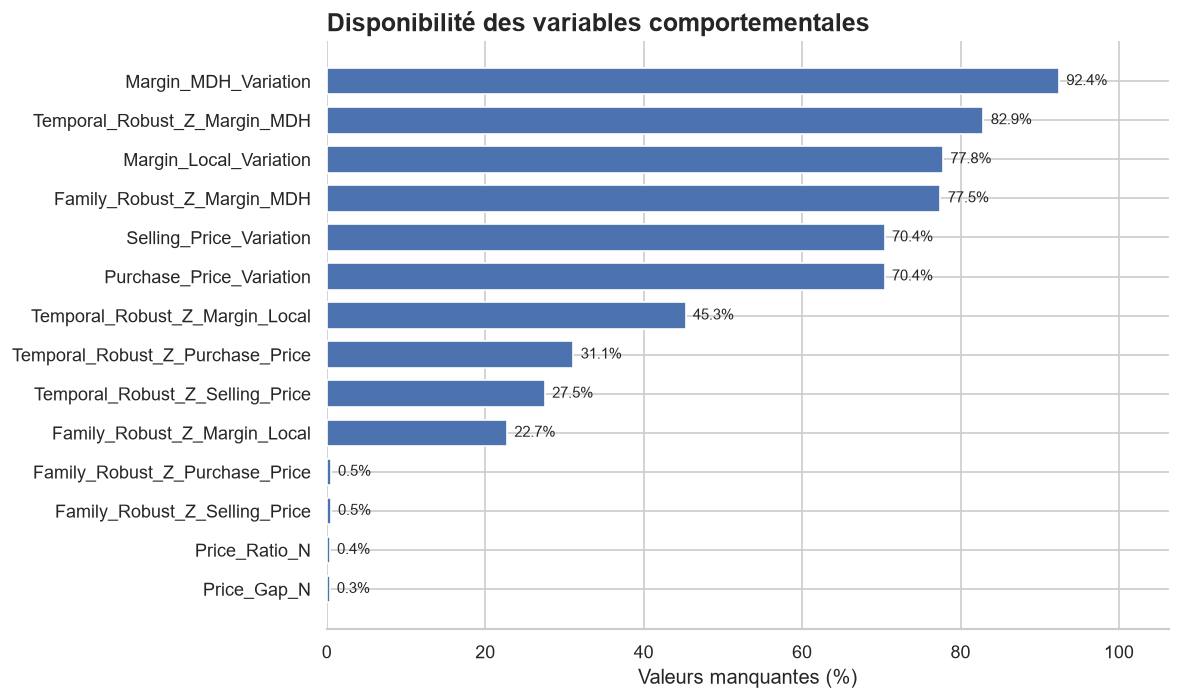

In [13]:
# Visualisation 1 — disponibilité des variables ML

fig, ax = plt.subplots(figsize=(10, 6))

plot_data = missing_ml.sort_values(ascending=True)

bars = ax.barh(
    plot_data.index,
    plot_data.values,
    height=0.68
)

ax.set_title("Disponibilité des variables comportementales", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Valeurs manquantes (%)")
ax.set_ylabel("")
ax.set_xlim(0, max(5, plot_data.max() * 1.15))

for bar, value in zip(bars, plot_data.values):
    ax.text(
        value + max(0.1, plot_data.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

sns.despine(ax=ax, left=True, bottom=False)
plt.tight_layout()
plt.show()

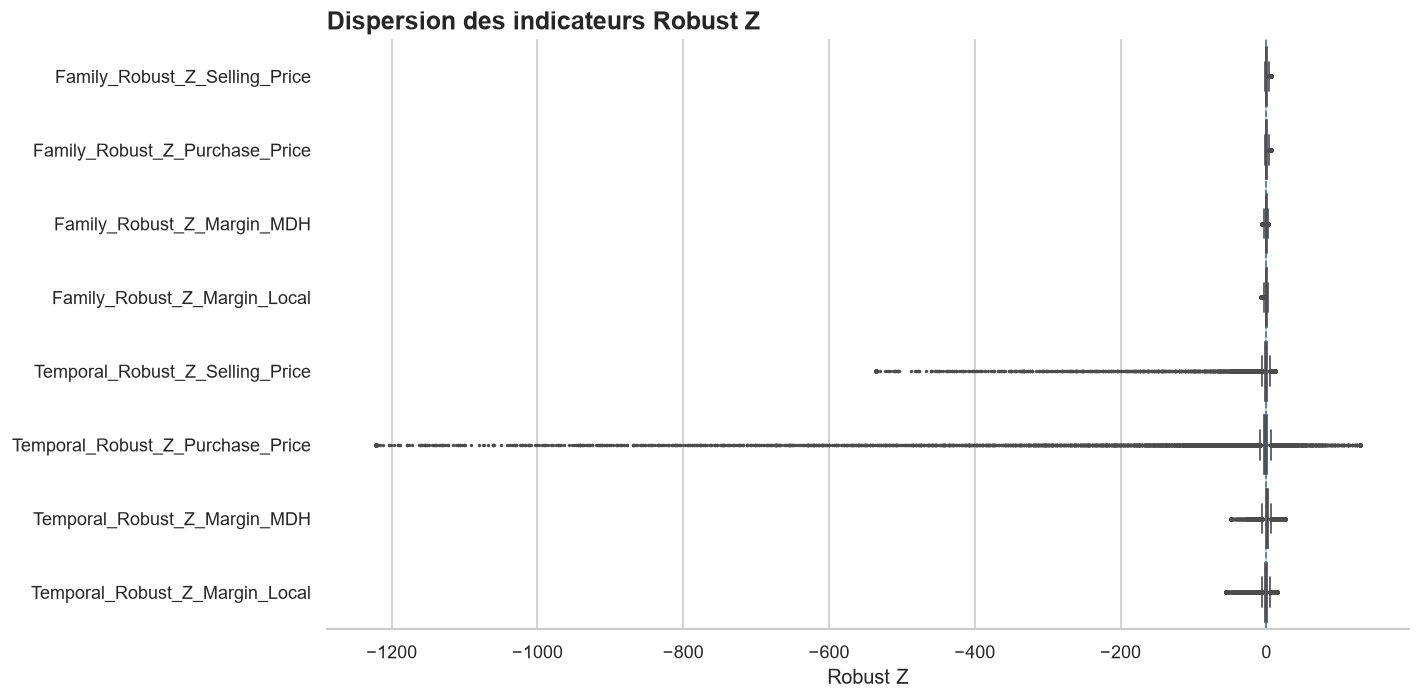

In [14]:
# Visualisation 2 — dispersion des Robust Z familiaux et temporels
robust_z_features = [
    "Family_Robust_Z_Selling_Price",
    "Family_Robust_Z_Purchase_Price",
    "Family_Robust_Z_Margin_MDH",
    "Family_Robust_Z_Margin_Local",
    "Temporal_Robust_Z_Selling_Price",
    "Temporal_Robust_Z_Purchase_Price",
    "Temporal_Robust_Z_Margin_MDH",
    "Temporal_Robust_Z_Margin_Local"
]

z_data = df_features[robust_z_features].copy()


for column in robust_z_features:
    low, high = z_data[column].quantile([0.01, 0.99])
    z_data[column] = z_data[column].clip(low, high)

z_long = z_data.melt(
    var_name="Variable",
    value_name="Robust Z"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=z_long,
    x="Robust Z",
    y="Variable",
    ax=ax,
    fliersize=1,
    linewidth=1
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Dispersion des indicateurs Robust Z", loc="left", fontsize=15, fontweight="bold")
ax.set_xlabel("Robust Z")
ax.set_ylabel("")

sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

## 6. Construction du dataset enrichi

Les colonnes techniques utilisées uniquement pour l'ordonnancement temporel sont
retirées du fichier final. Les variables de contexte restent disponibles pour
l'analyse et la restitution, tandis que les 14 variables comportementales
sélectionnées sont identifiées explicitement dans `ml_features`.

In [15]:
dataset_features = df_features.drop(
    columns=["_Month_Number", "_Period_Index"],
    errors="ignore"
).copy()

print(
    f"Dataset enrichi : {dataset_features.shape[0]:,} observations × "
    f"{dataset_features.shape[1]} variables"
)

print(f"Variables ML : {len(ml_features)}")

Dataset enrichi : 68,324 observations × 49 variables
Variables ML : 14


In [17]:
DATASET_FEATURES = PROCESSED_DIR / "dataset_features.csv"

dataset_features.to_csv(
    DATASET_FEATURES,
    index=False,
    encoding="utf-8-sig"
)

print(f" Dataset enrichi sauvegardé")

 Dataset enrichi sauvegardé


In [18]:
# Contrôles finaux
assert all(column in dataset_features.columns for column in ml_features)
assert dataset_features.shape[0] == df.shape[0]
assert not dataset_features[["EAN", "Year", "MonthLib"]].isna().all(axis=1).any()

summary = pd.DataFrame({
    "Indicateur": [
        "Observations d'entrée",
        "Observations de sortie",
        "Variables d'entrée",
        "Variables de sortie",
        "Variables comportementales ML",
        "Historique minimal",
        "Comparaison familiale minimale"
    ],
    "Valeur": [
        f"{len(df):,}",
        f"{len(dataset_features):,}",
        df.shape[1],
        dataset_features.shape[1],
        len(ml_features),
        f"{MIN_HISTORY_OBS} observations antérieures",
        f"{MIN_PEER_OBS} valeurs valides"
    ]
})

display(summary)

print(" FEATURE ENGINEERING TERMINÉ")

,Indicateur,Valeur
0,Observations d'entrée,"68,324"
1,Observations de sortie,"68,324"
2,Variables d'entrée,15
3,Variables de sortie,49
4,Variables comportementales ML,14
5,Historique minimal,3 observations antérieures
6,Comparaison familiale minimale,5 valeurs valides


 FEATURE ENGINEERING TERMINÉ
